## Импорты и настройки


In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
# Подключение Google диска
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
# Настройка выводов
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [72]:
info_dict = {
    "ID": "Номер записи",
    "shop_id": "Порядковый номер магазина",
    "item_id": "Порядковый номер товара",
    "item_category_id": "Порядковый номер категории",
    "item_cnt_day": "Продано за день",
    "item_price": "Цена товрара",
    "date": "Дата продажи dd/mm/yyyy",
    "date_block_num": "Порядковый номер месяца, используемый для удобства",
    "item_name": "Название товара",
    "shop_name": "Название магазина",
    "item_category_name": "Название категории товара",
}

In [73]:
def descr_features(data):
    # Отфильтруем столбцы, исключив те, что содержат 'id' в названии
    cols = [col for col in data.columns if 'id' not in col.lower()]
    data = data[cols]

    # Тип данных
    features = data.dtypes.to_frame(name="data_type")

    # Текстовое описание (предполагаем, что info_dict объявлен вне функции)
    features["meaning"] = [info_dict.get(x, "new") for x in features.index]

    # Кол-во и % пропусков
    features["n_NaN"] = data.isna().sum()
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2)

    # Количество уникальных значений
    features["nunique"] = data.nunique().values

    # Статистики describe()
    describe_train = data.describe(include="all").round(1).T
    features = pd.merge(
        features,
        describe_train.round(0),
        how="left",
        left_index=True,
        right_index=True
    )

    return features

## Загрузка данных

In [74]:
train = pd.read_csv("/content/drive/MyDrive/DS/data/sales_train.csv")
train.head(10)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0
5,10.01.2013,0,25,2564,349.00,1.0
6,02.01.2013,0,25,2565,549.00,1.0
7,04.01.2013,0,25,2572,239.00,1.0
8,11.01.2013,0,25,2572,299.00,1.0
9,03.01.2013,0,25,2573,299.00,3.0


In [75]:
# Парсинг дат
train['date'] = pd.to_datetime(train['date'], errors='coerce', format='%d.%m.%Y')

train["month"] = train["date"].apply(lambda x: x.month)
train["year"] = train["date"].apply(lambda x: x.year)

# Удаляем date_time признак
train = train.drop(columns=["date"])

In [76]:
items = pd.read_csv("/content/drive/MyDrive/DS/data/items.csv")
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [77]:
shops = pd.read_csv("/content/drive/MyDrive/DS/data/shops.csv")
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


## Проверка качества данных

In [78]:
train.head()

,date_block_num,shop_id,item_id,item_price,item_cnt_day,month,year
0,0,59,22154,999.00,1.0,1,2013
1,0,25,2552,899.00,1.0,1,2013
2,0,25,2552,899.00,-1.0,1,2013
3,0,25,2554,1709.05,1.0,1,2013
4,0,25,2555,1099.00,1.0,1,2013


In [79]:
# Описательная статистика
descr_features(train)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
date_block_num,int64,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,2935849.0,15.0,9.0,0.0,7.0,14.0,23.0,33.0
item_price,float64,Цена товрара,0,0.0,19993,2935849.0,891.0,1730.0,-1.0,249.0,399.0,999.0,307980.0
item_cnt_day,float64,Продано за день,0,0.0,198,2935849.0,1.0,3.0,-22.0,1.0,1.0,1.0,2169.0
month,int64,new,0,0.0,12,2935849.0,6.0,4.0,1.0,3.0,6.0,9.0,12.0
year,int64,new,0,0.0,3,2935849.0,2014.0,1.0,2013.0,2013.0,2014.0,2014.0,2015.0


### Полнота (Completeness)

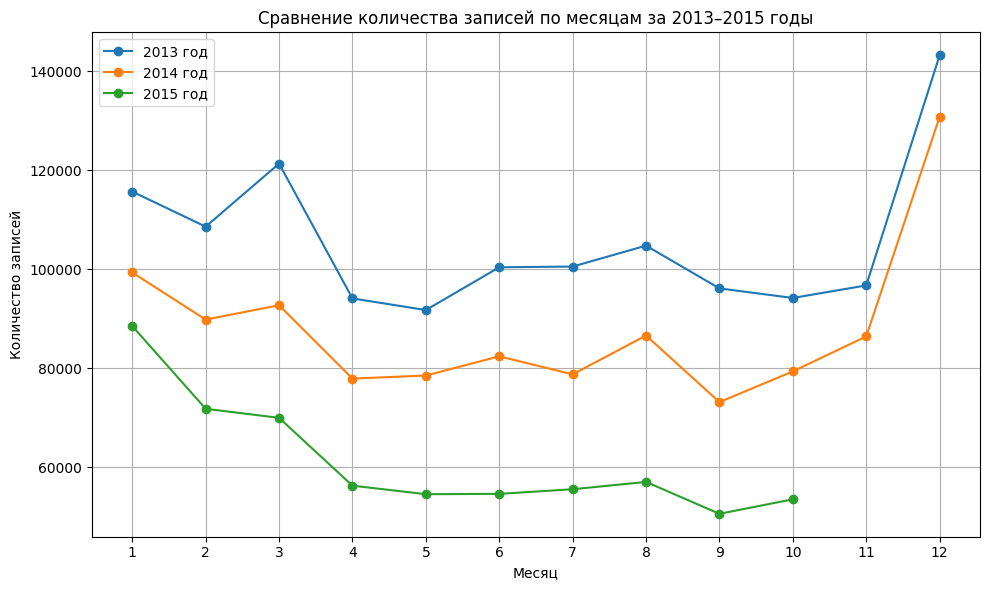

In [80]:
# Годы, которые хотим отобразить
years = [2013, 2014, 2015]

# Создание словаря для хранения данных по месяцам
monthly_data = {}

for year in years:
    data_year = train[train["year"] == year]
    month_counts = data_year["month"].value_counts().sort_index()
    monthly_data[year] = month_counts

# Построение одного графика с тремя кривыми
plt.figure(figsize=(10, 6))

for year in years:
    plt.plot(
        monthly_data[year].index,
        monthly_data[year].values,
        marker='o',
        label=f'{year} год'
    )

# Настройка графика
plt.title('Сравнение количества записей по месяцам за 2013–2015 годы')
plt.xlabel('Месяц')
plt.ylabel('Количество записей')
plt.xticks(range(1, 13))  # Месяцы от 1 до 12
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

График демонстрирует высокую полноту данных по каждому месяцу в течение трёх лет — 2013, 2014 и 2015 годов. Для каждого месяца представлено значительное количество записей, варьирующееся от 60,000 до 140,000, что свидетельствует о стабильной и равномерной представленности информации во времени. Это позволяет проводить надёжный сравнительный анализ сезонных колебаний.

**Вывод:** данные полные, пропусков нет.

### Уникальность (Uniqueness)

In [81]:
shops["shop_name"].unique()

array(['!Якутск Орджоникидзе, 56 фран', '!Якутск ТЦ "Центральный" фран',
       'Адыгея ТЦ "Мега"', 'Балашиха ТРК "Октябрь-Киномир"',
       'Волжский ТЦ "Волга Молл"', 'Вологда ТРЦ "Мармелад"',
       'Воронеж (Плехановская, 13)', 'Воронеж ТРЦ "Максимир"',
       'Воронеж ТРЦ Сити-Парк "Град"', 'Выездная Торговля',
       'Жуковский ул. Чкалова 39м?', 'Жуковский ул. Чкалова 39м²',
       'Интернет-магазин ЧС', 'Казань ТЦ "Бехетле"',
       'Казань ТЦ "ПаркХаус" II', 'Калуга ТРЦ "XXI век"',
       'Коломна ТЦ "Рио"', 'Красноярск ТЦ "Взлетка Плаза"',
       'Красноярск ТЦ "Июнь"', 'Курск ТЦ "Пушкинский"',
       'Москва "Распродажа"', 'Москва МТРЦ "Афи Молл"',
       'Москва Магазин С21', 'Москва ТК "Буденовский" (пав.А2)',
       'Москва ТК "Буденовский" (пав.К7)', 'Москва ТРК "Атриум"',
       'Москва ТЦ "Ареал" (Беляево)', 'Москва ТЦ "МЕГА Белая Дача II"',
       'Москва ТЦ "МЕГА Теплый Стан" II',
       'Москва ТЦ "Новый век" (Новокосино)', 'Москва ТЦ "Перловский"',
       'Москва Т

Некоторые названия магазинов встречаются по 2 раза: Якутск Орджоникидзе, 56; Якутск ТЦ "Центральный; Жуковский ул. Чкалова 39м².

In [82]:
print(f"Количество дубликатов в товарах по id: {items['item_id'].duplicated().sum()}")

print(f"Количество дубликатов в товарах: {items.duplicated().sum()}")
print(f"Процент дубликатов в товарах: {items.duplicated().sum()/train.shape[0]}\n")

Количество дубликатов в товарах по id: 0
Количество дубликатов в товарах: 0
Процент дубликатов в товарах: 0.0



In [83]:
print(f"Количество дубликатов в магазинах по id: {shops['shop_id'].duplicated().sum()}")
print(f"Количество дубликатов в магазинах: {shops.duplicated().sum()}")
print(f"Процент дубликатов в магазинах: {shops.duplicated().sum()/train.shape[0]}\n")

Количество дубликатов в магазинах по id: 0
Количество дубликатов в магазинах: 0
Процент дубликатов в магазинах: 0.0



In [84]:
# Выделим полные дубликаты
dups = train[train.duplicated()]
print(f"Количество дубликатов: {dups.shape[0]}")
print(f"Процент дубликатов: {dups.shape[0]/train.shape[0]}\n")

Количество дубликатов: 1033632
Процент дубликатов: 0.3520726031890605



In [85]:
dups.sample(30, random_state=42)

,date_block_num,shop_id,item_id,item_price,item_cnt_day,month,year
169563,1,7,12168,189.0,1.0,2,2013
953448,9,35,8058,500.0,1.0,10,2013
2475117,25,25,14932,699.0,1.0,2,2015
858643,8,18,4181,1090.0,1.0,9,2013
2537794,26,28,21669,149.0,1.0,3,2015
1203796,11,54,11842,48.0,1.0,12,2013
1450571,13,54,17978,149.0,1.0,2,2014
1232075,11,35,19028,399.0,1.0,12,2013
1510490,14,31,8682,149.0,1.0,3,2014
2297879,23,27,1460,599.0,1.0,12,2014


Дубикаты в данных разнородны. Они не принадлежат конкретному магазину или товару, появились в разные даты. Процент дубликатов не мал (полностью идентичных строк 35%).

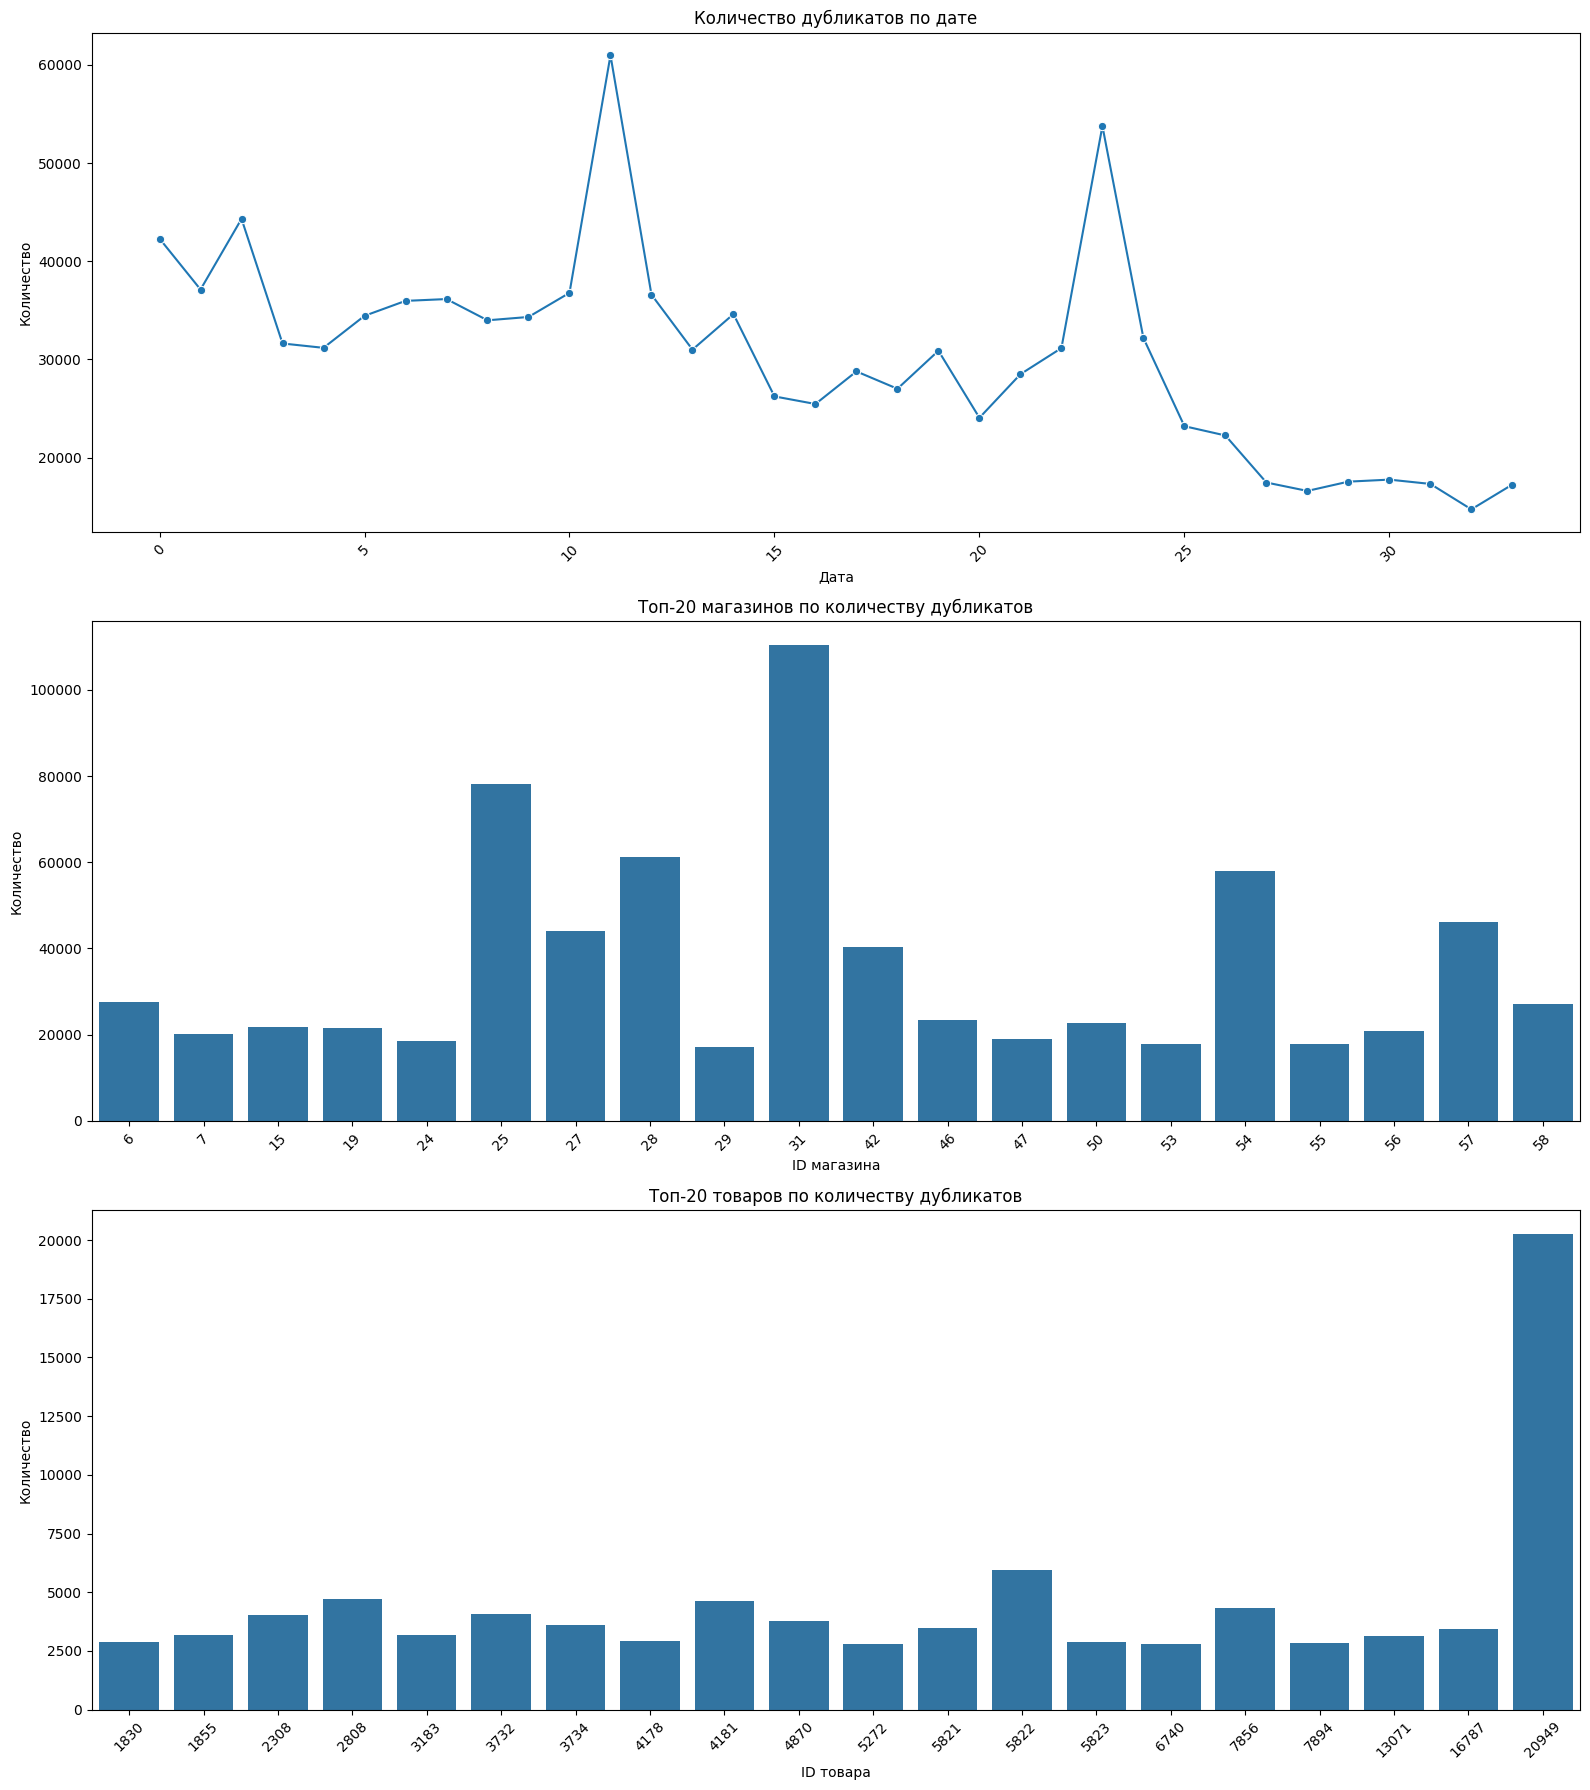

In [86]:
# Подготовка данных
date_counts = dups['date_block_num'].value_counts().sort_index()
store_counts = dups['shop_id'].value_counts().head(20)
item_counts = dups['item_id'].value_counts().head(20)

fig, axes = plt.subplots(3, 1, figsize=(16, 18));

# 1. Дубликаты по дате
sns.lineplot(ax=axes[0], x=date_counts.index, y=date_counts.values, marker='o');
axes[0].set_title('Количество дубликатов по дате')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# 2. Дубликаты по магазинам
sns.barplot(ax=axes[1], x=store_counts.index, y=store_counts.values);
axes[1].set_title('Топ-20 магазинов по количеству дубликатов')
axes[1].set_xlabel('ID магазина')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)

# 3. Дубликаты по товарам
sns.barplot(ax=axes[2], x=item_counts.index, y=item_counts.values);
axes[2].set_title('Топ-20 товаров по количеству дубликатов')
axes[2].set_xlabel('ID товара')
axes[2].set_ylabel('Количество')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- График показывает, как количество дубликатов менялось по датам, с заметными пиками около 10-го и 25-го числа. Это может указывать на повторные загрузки данных или сбои в процессе обработки.
- На графике видно, что магазин с ID 31 имеет наибольшее количество дубликатов, что может свидетельствовать о сбое при загрузке или повторной выгрузке данных именно по этому магазину.
- На графике видно, что товар с ID 10949 имеет наибольшее количество дубликатов. Это может указывать на ошибку в учёте или повторную загрузку данных по конкретному товару.

**Вывод:** условие уникальности не выполняется, в данных 35% полностью идентичных строк (возможные сбои в загрузке данных), которые можно безопасно удалить. После удаления стоит проверить, не изменились ли ключевая метрика.

### Согласованность (Consistency)

In [87]:
# Группировка по году и месяцу, получение уникальных date_block_num
aggregated = train.groupby(['year', 'month'])['date_block_num'].unique().reset_index()

# Вывод результата
aggregated

,year,month,date_block_num
0,2013,1,[0]
1,2013,2,[1]
2,2013,3,[2]
3,2013,4,[3]
4,2013,5,[4]
5,2013,6,[5]
6,2013,7,[6]
7,2013,8,[7]
8,2013,9,[8]
9,2013,10,[9]


In [88]:
# Магазины
missing_shops = set(train['shop_id']) - set(shops['shop_id'])
print(f'Магазины без описания: {missing_shops}')

# Товары
missing_items = set(train['item_id']) - set(items['item_id'])
print(f'Товары без описания: {missing_items}')

Магазины без описания: set()
Товары без описания: set()


In [89]:
merged = train.merge(items, on='item_id', how='left')

missing_after_merge = merged['item_name'].isnull().sum()
print(f'Строк без названия товара после merge: {missing_after_merge}')

missing_after_merge = merged['item_category_id'].isnull().sum()
print(f'Строк без категории товара после merge: {missing_after_merge}')

Строк без названия товара после merge: 0
Строк без категории товара после merge: 0


In [90]:
merged = train.merge(shops, on='shop_id', how='left')

missing_after_merge = merged['shop_name'].isnull().sum()
print(f'Строк без названия магазина после merge: {missing_after_merge}')

Строк без названия магазина после merge: 0


**Вывод:** признаки согласованны.
- Каждый номер date_block_num соответствует уникальной комбинации месяца и года.
- Всем магазинам и товарам соответствует описание из соответствующих таблиц.
- full джойны не привели к потере информации

### Актуальность (Timeliness)

In [91]:
print("Годы наблюдений в тренировочной выборке:", train.year.unique())

Годы наблюдений в тренировочной выборке: [2013 2014 2015]


**Вывод:** данные актуальны так как мы делаем прогноз на 2015 год.

### Точность (Accuracy)

Как видно из датафрейма со статистиками, диапазон цены [-1; 307980] условных единиц.

In [92]:
train["item_price"].min()

-1.0

In [93]:
train["item_price"].max()

307980.0

In [94]:
train[train["item_price"]==-1]

,date_block_num,shop_id,item_id,item_price,item_cnt_day,month,year
484683,4,32,2973,-1.0,1.0,5,2013


Вот список возможных причин появления отрицательной цены:

- Ошибка загрузки или трансформации данных — неверное считывание из файла, округление или преобразование типов.

- Некорректное отражение возврата — возврат товара записан через отрицательную цену вместо отрицательного количества. **Возврат в наших данных обозначен через отрицательное количество (количество колеблется от -22 до 2169)**

- Тестовая или мусорная запись — строка могла быть добавлена для проверки и случайно осталась в финальной выборке.

Такая строка одна, поэтому её целесообразно удалить

**Вывод:** в признаке цены есть значение -1, в остальном данные точны.

###Валидность (Validity)

In [95]:
train.dtypes

,0
date_block_num,int64
shop_id,int64
item_id,int64
item_price,float64
item_cnt_day,float64
month,int64
year,int64


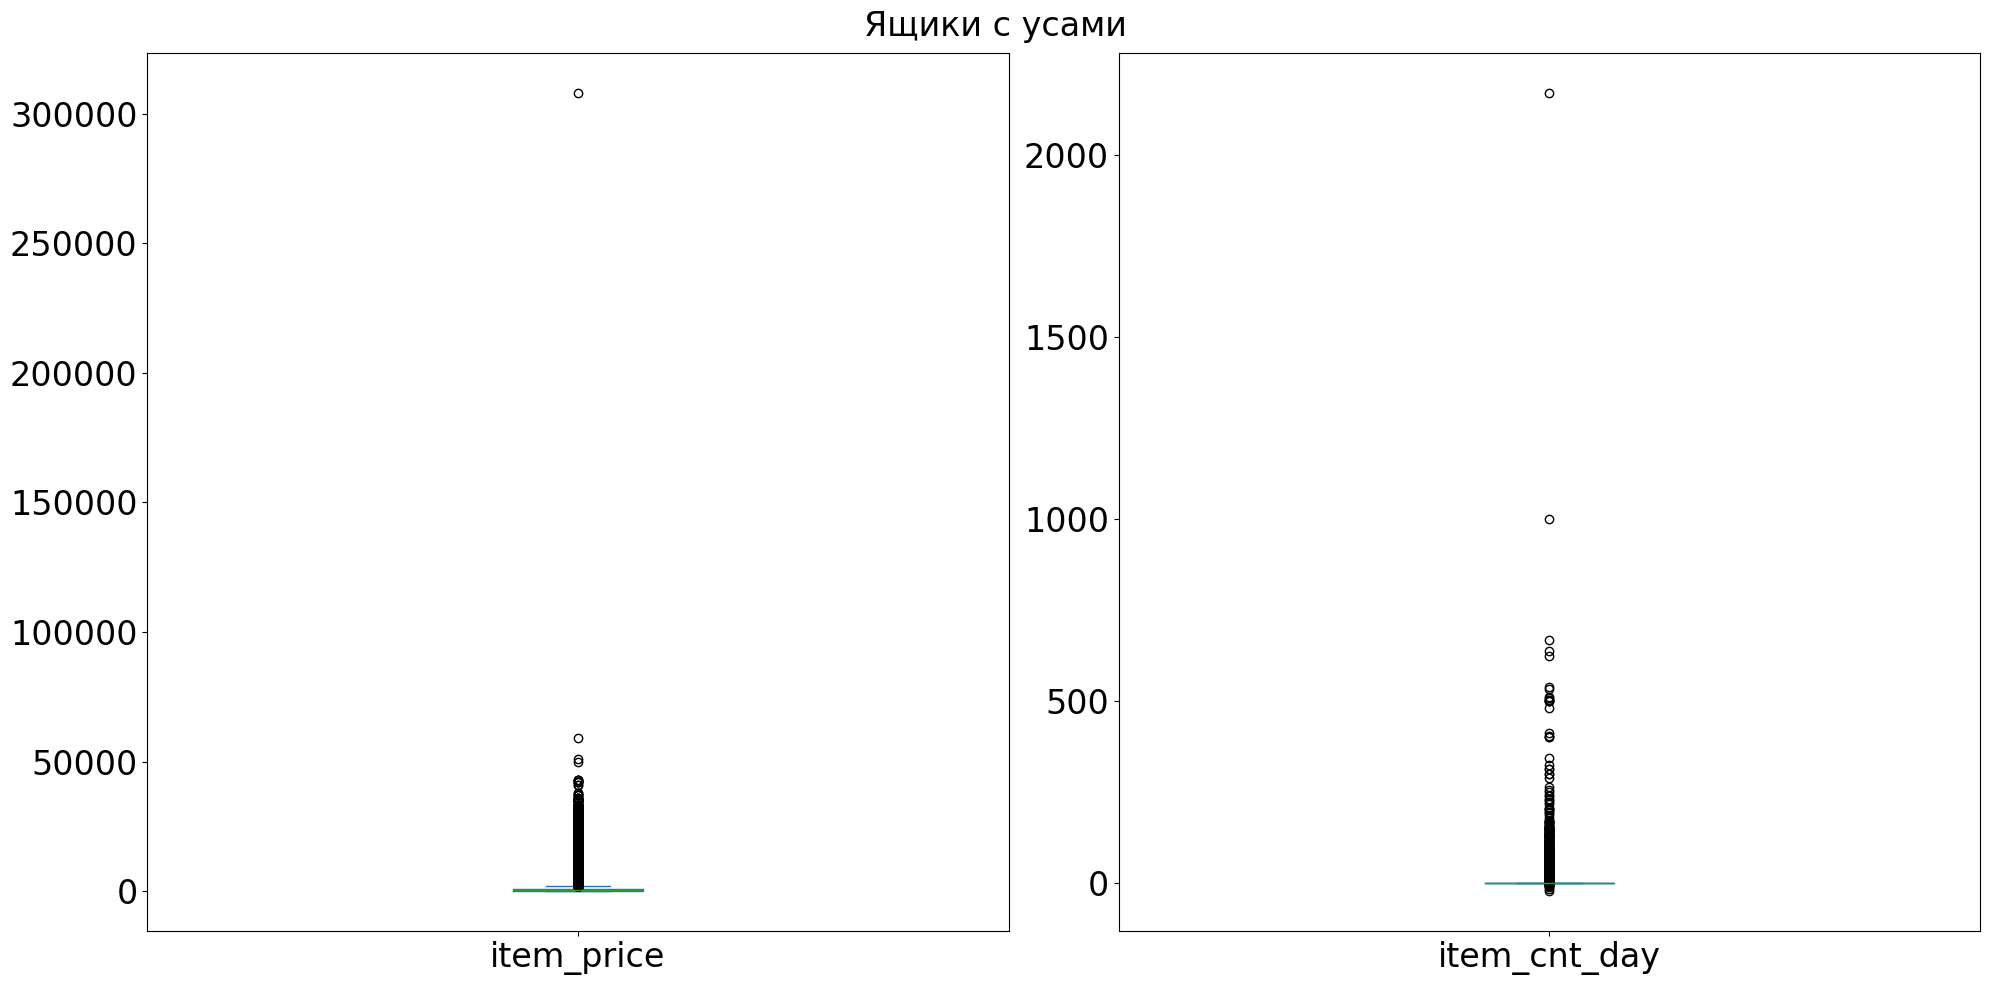

In [96]:
# Построение боксплотов
ax = train[["item_price", "item_cnt_day", ]].plot(kind="box", subplots=True, figsize=(20, 10), fontsize=24)
plt.suptitle("Ящики с усами", fontsize=24, x=0.5)

# Настройка макета
plt.tight_layout()

In [97]:
def get_bounds(data, column):
    q25 = data[column].quantile(0.25) # Рассчёт интерквартильного размаха
    q75 = data[column].quantile(0.75)
    iqr = q75 - q25
    bound = (q25 - iqr * 1.5, q75 + iqr * 1.5)
    out_of_bound = ( data[column] > bound[1]) | ( data[column] < bound[0])
    anom_count = data[column][ out_of_bound ].count()

    print("\033[1m",column,"\033[0m")
    print("Интерквартильный размах", bound)
    print(f"Диапазон значений: ({data[column].min()}; {data[column].max()})")
    print("Количество выбросов: ", anom_count)
    print("Их процент в выборке: ", anom_count / len(data) * 100, '\n')

    return [bound[0], bound[1], out_of_bound]

In [98]:
for col in train.columns:
  get_bounds(train, col)

 date_block_num 
Интерквартильный размах (np.float64(-17.0), np.float64(47.0))
Диапазон значений: (0; 33)
Количество выбросов:  0
Их процент в выборке:  0.0 

 shop_id 
Интерквартильный размах (np.float64(-15.5), np.float64(84.5))
Диапазон значений: (0; 59)
Количество выбросов:  0
Их процент в выборке:  0.0 

 item_id 
Интерквартильный размах (np.float64(-12336.0), np.float64(32496.0))
Диапазон значений: (0; 22169)
Количество выбросов:  0
Их процент в выборке:  0.0 

 item_price 
Интерквартильный размах (np.float64(-876.0), np.float64(2124.0))
Диапазон значений: (-1.0; 307980.0)
Количество выбросов:  258942
Их процент в выборке:  8.820004026092624 

 item_cnt_day 
Интерквартильный размах (np.float64(1.0), np.float64(1.0))
Диапазон значений: (-22.0; 2169.0)
Количество выбросов:  306477
Их процент в выборке:  10.439126807952317 

 month 
Интерквартильный размах (np.float64(-6.0), np.float64(18.0))
Диапазон значений: (1; 12)
Количество выбросов:  0
Их процент в выборке:  0.0 

 year 
Инте

**Вывод:** признак кличества проданных товаров имеет целочисленный тип, целесообразно привести тип float в int. В принаках цены и количества проданных тваров есть выбросы, однако эти значения не ошибка, а вполне вероятные большие значения. Исходные данные вылидны.

### Однозначность (Clarity)

In [99]:
# Проверка уникальности ключей
print("item_id уникален:", items['item_id'].is_unique)
print("item_category_id уникален:", items['item_category_id'].is_unique)
print("shop_id уникален:", shops['shop_id'].is_unique)

item_id уникален: True
item_category_id уникален: False
shop_id уникален: True


In [100]:
# Проверка однозначности соответствий

print("Каждому item_id соответствует одна категория:",
      items.groupby('item_id')['item_category_id'].nunique().max() == 1)

print("Каждому item_id соответствует одно название:",
      items.groupby('item_id')['item_name'].nunique().max() == 1)

print("Каждому shop_id соответствует одно название:",
      shops.groupby('shop_id')['shop_name'].nunique().max() == 1)


Каждому item_id соответствует одна категория: True
Каждому item_id соответствует одно название: True
Каждому shop_id соответствует одно название: True


In [101]:
# Проверка атомарности признаков

def check_atomic(column):
    return column.apply(lambda x: isinstance(x, (int, float, str)) and not isinstance(x, (list, tuple, dict)))

atomic_items = items.apply(check_atomic).all().all()
atomic_shops = shops.apply(check_atomic).all().all()
atomic_sales = train.apply(check_atomic).all().all()


print("Все значения в товарах атомарны:", atomic_items)
print("Все значения в магазинах атомарны:", atomic_shops)
print("Все значения в продажах атомарны:", atomic_sales)

Все значения в товарах атомарны: True
Все значения в магазинах атомарны: True
Все значения в продажах атомарны: True


**Вывод:** данные однозначны. Каждому товару соответсвует 1 категория и название. Каждому магазину соответствует 1 название. В признаках значения атомарны.

### Итог

**ВЫВОД О КАЧЕСТВЕ ДАННЫХ:** данные хорошего качества, размер датафрейма подходит для обучения моделей. Необходимы удаление дубликатов и неинформативных признаков, приведение типов, обработка выбросов и некорректных значений.